In [ ]:
import os

os.environ["ROBOFLOW_API_KEY"] = "vsMXTZGbvqCJvXqOX1dv"

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("rewan-srour").project("license-plate-recognition-rxg4e-fhfcw")
version = project.version(1)
dataset = version.download("yolov11")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-1 in yolov11:: 100%|██████████| 48483/48483 [00:28<00:00, 1705.11it/s]


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.2 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/yt7589/yolov11.git

Cloning into 'yolov11'...
remote: Enumerating objects: 28528, done.
remote: Total 28528 (delta 0), reused 0 (delta 0), pack-reused 28528 (from 1)
Receiving objects: 100% (28528/28528), 16.72 MiB | 22.04 MiB/s, done.
Resolving deltas: 100% (20523/20523), done.


In [ ]:
import os
import cv2
import yaml
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
yaml_path = "/content/License-Plate-Recognition-1/data.yaml"

with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

data

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 1,
 'names': ['License_Plate'],
 'roboflow': {'workspace': 'rewan-srour',
  'project': 'license-plate-recognition-rxg4e-fhfcw',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/rewan-srour/license-plate-recognition-rxg4e-fhfcw/dataset/1'}}

In [ ]:
print("Number of classes:", data["nc"])
print("Class names:", data["names"])

Number of classes: 1
Class names: ['License_Plate']


Number of training images: 21171
First image: pic_368_jpg.rf.d3fdb52f9fbccf2dc77df8c79cb45a7e.jpg


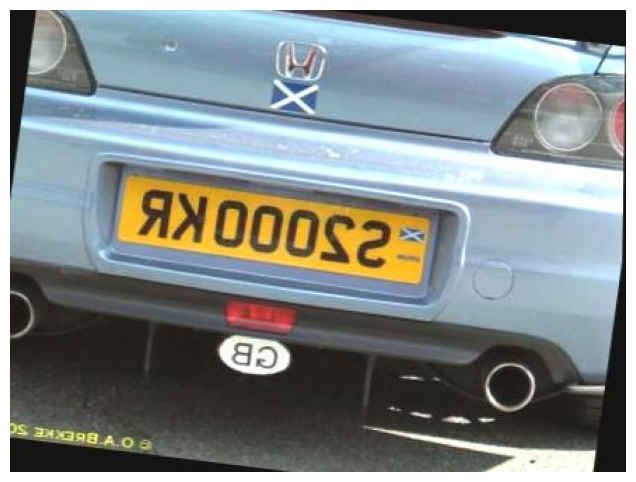

In [ ]:
train_images_path = "/content/License-Plate-Recognition-1/train/images"

images = os.listdir(train_images_path)

print("Number of training images:", len(images))
print("First image:", images[0])
image_path = os.path.join(train_images_path, images[0])

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
#[x_center, y_center, W, H],  (x_min, y_min, x_max, y_max)
def yolobbox(bbox):
  x_min,y_min=bbox[0] -bbox[2]/2 ,bbox[1] - bbox[3]/2
  x_max,y_max=bbox[0] + bbox[2]/2,bbox[1] + bbox[3]/2
  return x_min,y_min,x_max,y_max

In [ ]:
images_path = "/content/License-Plate-Recognition-1/train/images"
labels_path = "/content/License-Plate-Recognition-1/train/labels"

class_names = ["License_Plate"]

colors = np.random.uniform(0,255,size=(len(class_names), 3))


In [ ]:
def plot_box(image, bboxes, labels):

    h, w, _ = image.shape

    for box_num, box in enumerate(bboxes):

        x1, y1, x2, y2 = yolobbox(box)

        xmin = int(x1 * w)
        ymin = int(y1 * h)

        xmax = int(x2 * w)
        ymax = int(y2 * h)

        class_id = int(labels[box_num])

        class_name = class_names[class_id]

        color = colors[class_id]

        color = tuple(map(int, color))

        cv2.rectangle(
            image,

            # top-left
            (xmin, ymin),

            # bottom-right
            (xmax, ymax),

            color=color,

            thickness=2
        )

        font_scale = 0.7
        font_thickness = 2

        (text_width, text_height), baseline = cv2.getTextSize(
            class_name,
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            font_thickness
        )


        cv2.rectangle(
            image,

            (xmin, ymin - text_height - 10),

            (xmin + text_width, ymin),

            color=color,

            thickness=-1
        )


        cv2.putText(
            image,

            class_name,

            (xmin, ymin - 5),

            cv2.FONT_HERSHEY_SIMPLEX,

            font_scale,

            (255, 255, 255),

            font_thickness
        )


    return image




Image: CarLongPlate237_jpg.rf.8a45de5aeb77ed838f2d13ed61bf0fba.jpg
Label: CarLongPlate237_jpg.rf.8a45de5aeb77ed838f2d13ed61bf0fba.txt

Number of bounding boxes: 1

Bounding boxes:
[[0.6003217200251099, 0.31204009289817874, 0.2533741368487132, 0.1183718371837184]]

Labels:
[0]


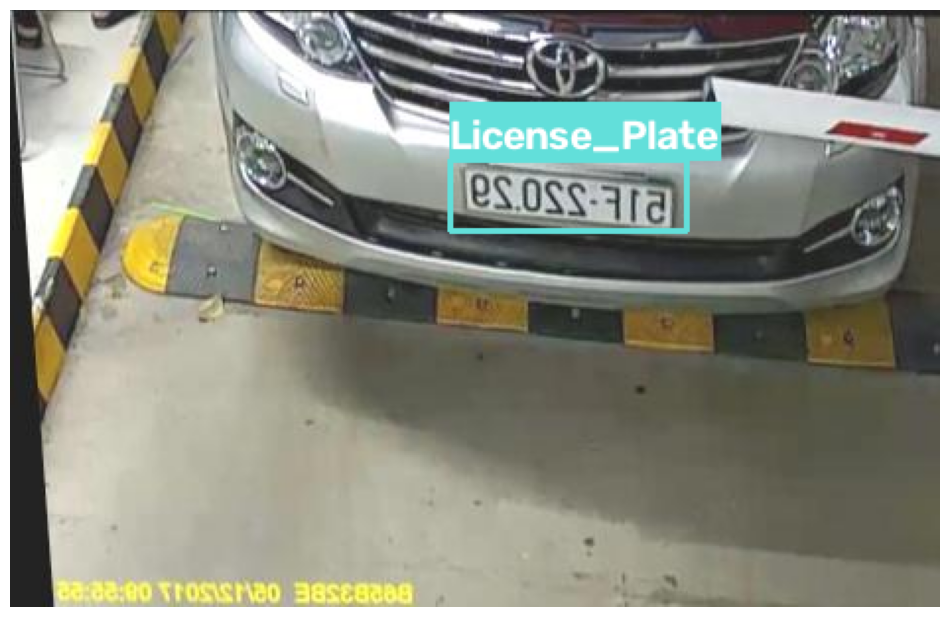

In [ ]:
image_files = os.listdir(images_path)

image_name = image_files[11]

print("Image:", image_name)

image_path = os.path.join(
    images_path,
    image_name
)

label_name = os.path.splitext(image_name)[0] + ".txt"

label_path = os.path.join(
    labels_path,
    label_name
)

print("Label:", label_name)



image = cv2.imread(image_path)


if image is None:

    print("❌ Could not read image")

else:

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

bboxes = []
labels = []


with open(label_path, "r") as file:

    for line in file:

        values = line.strip().split()

        if not values:
            continue
        class_id = int(values[0])
        x_center = float(values[1])
        y_center = float(values[2])
        width = float(values[3])
        height = float(values[4])

        bboxes.append([
            x_center,
            y_center,
            width,
            height
        ])


        labels.append(class_id)

print("\nNumber of bounding boxes:", len(bboxes))

print("\nBounding boxes:")
print(bboxes)

print("\nLabels:")
print(labels)

result = plot_box(
    image.copy(),
    bboxes,
    labels
)


plt.figure(figsize=(12, 8))

plt.imshow(result)

plt.axis("off")

plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(data='/content/License-Plate-Recognition-1/data.yaml',epochs=50,imgsz=640,batch=16)

In [ ]:
!cp /content/runs/detect/train/weights/best.pt /content/best_license_plate.pt
!cp /content/runs/detect/train/weights/last.pt /content/last_license_plate.pt

In [ ]:
from google.colab import files
files.download("/content/best_license_plate.pt")
files.download("/content/last_license_plate.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
metrics = model.val(
    data="/content/License-Plate-Recognition-1/data.yaml"
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 12,675 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 666.1±210.5 MB/s, size: 19.8 KB)
val: Scanning /content/License-Plate-Recognition-1/valid/labels.cache... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 452.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 6.8it/s 18.7s
                   all       2048       2195      0.985      0.939      0.967      0.673
Speed: 0.9ms preprocess, 3.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-2


In [ ]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

mAP50: 0.96730882365465
mAP50-95: 0.6729481095234162


In [ ]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Precision: 0.9849294908968026
Recall: 0.9389521640091116


In [ ]:
import glob
from IPython.display import display
from PIL import Image

In [ ]:
model=YOLO("/content/runs/detect/train/weights/best.pt")


test_images = glob.glob("/content/License-Plate-Recognition-1/test/images/*")

print("Number of test images:", len(test_images))

results = model.predict(
    source=test_images[:20],
    conf=0.25,
    save=True
)

Number of test images: 1020

0: 640x640 1 License_Plate, 4.6ms
1: 640x640 1 License_Plate, 4.6ms
2: 640x640 1 License_Plate, 4.6ms
3: 640x640 1 License_Plate, 4.6ms
4: 640x640 1 License_Plate, 4.6ms
5: 640x640 1 License_Plate, 4.6ms
6: 640x640 1 License_Plate, 4.6ms
7: 640x640 1 License_Plate, 4.6ms
8: 640x640 1 License_Plate, 4.6ms
9: 640x640 1 License_Plate, 4.6ms
10: 640x640 1 License_Plate, 4.6ms
11: 640x640 1 License_Plate, 4.6ms
12: 640x640 1 License_Plate, 4.6ms
13: 640x640 1 License_Plate, 4.6ms
14: 640x640 1 License_Plate, 4.6ms
15: 640x640 1 License_Plate, 4.6ms
16: 640x640 1 License_Plate, 4.6ms
17: 640x640 1 License_Plate, 4.6ms
18: 640x640 1 License_Plate, 4.6ms
19: 640x640 1 License_Plate, 4.6ms
Speed: 1.8ms preprocess, 4.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


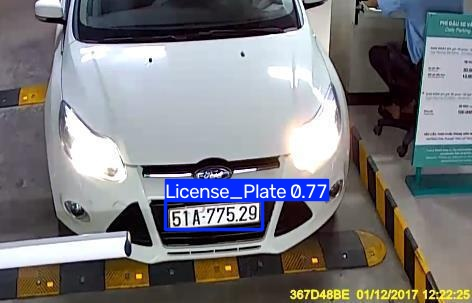

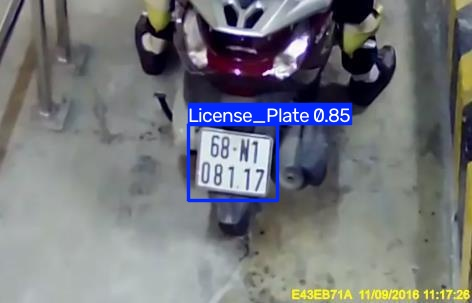

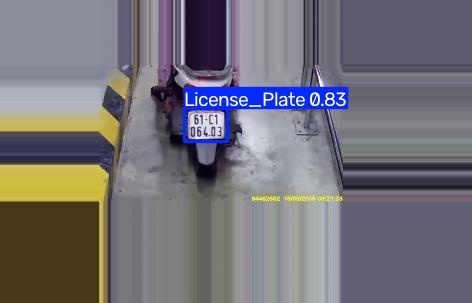

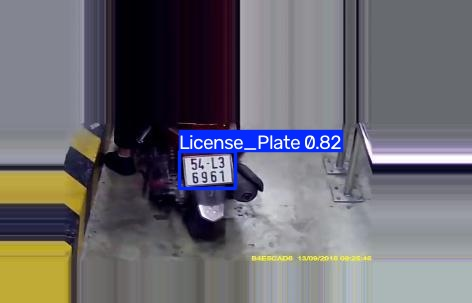

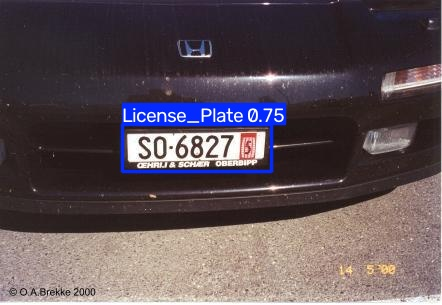

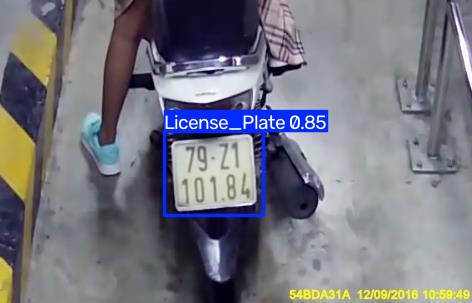

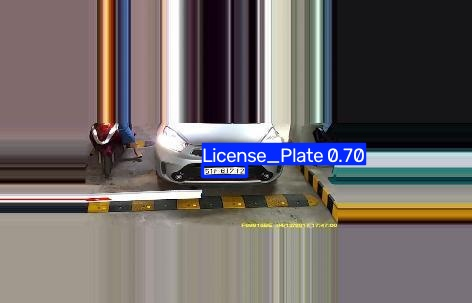

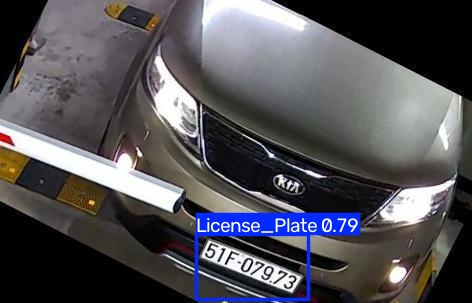

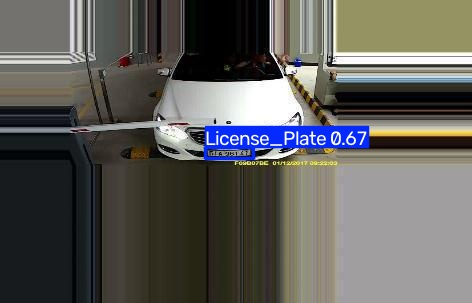

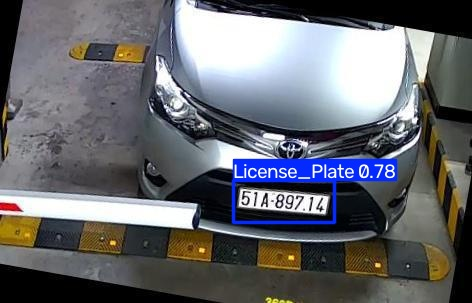

In [ ]:
predicted_images = glob.glob("/content/runs/detect/predict/*")

for img_path in predicted_images[:10]:
    display(Image.open(img_path))


image 1/1 /content/images (1).jpg: 640x640 1 License_Plate, 8.8ms
Speed: 3.0ms preprocess, 8.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-3


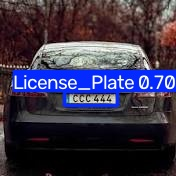

Detected: License_Plate | Confidence: 70.16%


In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import glob
import os

model = YOLO("/content/runs/detect/train/weights/best.pt")

image_path = "/content/images (1).jpg"

results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

save_dir = results[0].save_dir
output_images = glob.glob(os.path.join(save_dir, "*"))

display(Image.open(output_images[0]))

for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    name = model.names[cls]

    print(f"Detected: {name} | Confidence: {conf:.2%}")


image 1/1 /content/images (2).jpg: 384x640 1 License_Plate, 27.3ms
Speed: 1.7ms preprocess, 27.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-4


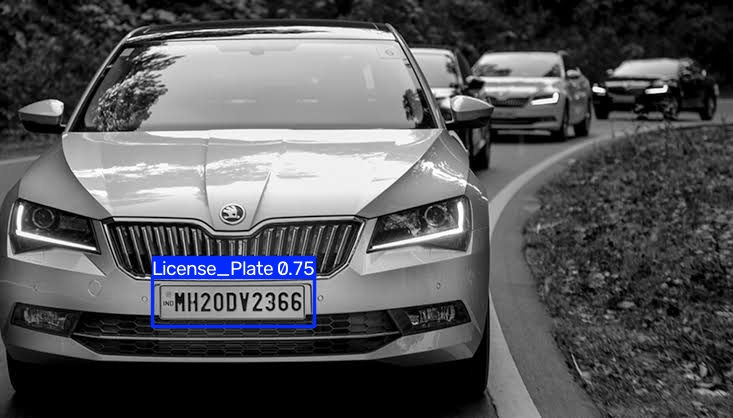

Detected: License_Plate | Confidence: 74.79%


In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import glob
import os

model = YOLO("/content/runs/detect/train/weights/best.pt")
image_path = "/content/images (2).jpg"
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)

save_dir = results[0].save_dir
output_images = glob.glob(os.path.join(save_dir, "*"))

display(Image.open(output_images[0]))

for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    name = model.names[cls]

    print(f"Detected: {name} | Confidence: {conf:.2%}")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 854745-hd_1280_720_50fps.mp4 to 854745-hd_1280_720_50fps.mp4


In [ ]:
from ultralytics import YOLO
from IPython.display import Video, display

# Load trained model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Video path
video_path = "/content/854745-hd_1280_720_50fps.mp4"

# Run prediction
results = model.predict(
    source=video_path,
    conf=0.25,
    save=True
)

# Get output video
output_video = str(results[0].save_dir / video_path.split("/")[-1])

print("Output video:", output_video)

# Display video
display(Video(output_video, embed=True))


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3000) /content/854745-hd_1280_720_50fps.mp4: 384x640 (no detections), 17.7ms
video 1/1 (frame 2/3000) /content/854745-hd_1280_720_50fps.mp4: 384x640 (no detections), 21.0ms
video 1/1 (frame 3/3000) /content/854745-hd_1280_720_50fps.mp4: 384x640 (no detections), 19.1ms
video 1/1 (frame 4/3000) /content/854745-hd_1280_720_50fps.mp4: 384x640 (no detections), 17.0ms
video 1/1 (frame 5/3000) /content/854745-hd_1280_720_50fps.mp4: 384x640 (no

KeyboardInterrupt: 

In [ ]:
model = YOLO("/content/best (1).pt")

print("Best weight loaded successfully!")

Best weight loaded successfully!


In [ ]:
import os
video_path = "/content/2103099-uhd_3840_2160_30fps.mp4"

if os.path.exists(video_path):
    print("Video found!")
else:
    print("Video not found!")

Video found!


In [ ]:
results = model.predict(
    source=video_path,
    save=True,
    conf=0.25,
    imgsz=640
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1800) /content/2103099-uhd_3840_2160_30fps.mp4: 384x640 3 License_Plates, 213.9ms
video 1/1 (frame 2/1800) /content/2103099-uhd_3840_2160_30fps.mp4: 384x640 2 License_Plates, 179.4ms
video 1/1 (frame 3/1800) /content/2103099-uhd_3840_2160_30fps.mp4: 384x640 2 License_Plates, 217.0ms
video 1/1 (frame 4/1800) /content/2103099-uhd_3840_2160_30fps.mp4: 384x640 2 License_Plates, 196.2ms
video 1/1 (frame 5/1800) /content/2103099-uhd_3840_2160

In [ ]:
import cv2

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

start_frame = 154
end_frame = 500

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

output_path = "/content/output_154_to_500.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

for frame_number in range(start_frame, end_frame):

    ret, frame = cap.read()

    if not ret:
        break

    result = model.predict(
        source=frame,
        conf=0.25,
        imgsz=640,
        verbose=False
    )[0]

    annotated_frame = result.plot()

    out.write(annotated_frame)

cap.release()
out.release()

print("Finished!")
print("Output saved to:", output_path)

Finished!
Output saved to: /content/output_154_to_500.mp4


In [ ]:
import cv2

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

output_path = "/content/yolo_full_video.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_number = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    result = model.predict(
        source=frame,
        conf=0.25,
        imgsz=640,
        verbose=False
    )[0]

    annotated_frame = result.plot()

    out.write(annotated_frame)

    frame_number += 1

    if frame_number % 50 == 0:
        print(f"Processed {frame_number}/{total_frames} frames")

cap.release()
out.release()

print("✅ Finished!")
print("Total frames:", frame_number)
print("Video saved at:", output_path)

Processed 50/1800 frames
Processed 100/1800 frames
Processed 150/1800 frames
✅ Finished!
Total frames: 154
Video saved at: /content/yolo_full_video.mp4


In [2]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5

In [ ]:
!pip install paddlepaddle
!pip install paddleocr

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from paddleocr import PaddleOCR


In [ ]:
model = YOLO("/content/best (1).pt")

ocr = PaddleOCR(use_angle_cls=True, lang='en')

print("YOLO + PaddleOCR جاهزين!")


/tmp/ipykernel_11448/847656780.py:4: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

YOLO + PaddleOCR جاهزين!


In [1]:
!pip install -U paddlepaddle
!pip install -U paddleocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!nvidia-smi

Wed Sep 23 10:26:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [6]:
!pip uninstall paddlepaddle -y

Found existing installation: paddlepaddle 3.3.1
Uninstalling paddlepaddle-3.3.1:
  Successfully uninstalled paddlepaddle-3.3.1


In [7]:
!python -m pip index versions paddlepaddle-gpu

ERROR: No matching distribution found for paddlepaddle-gpu


In [8]:
!which python
!python --version

/usr/local/bin/python
Python 3.13.15


In [10]:
!pip uninstall -y paddlepaddle

In [11]:
!pip install paddlepaddle-gpu==3.3.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu126/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 571.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install paddlepaddle-gpu

ERROR: Could not find a version that satisfies the requirement paddlepaddle-gpu (from versions: none)
ERROR: No matching distribution found for paddlepaddle-gpu


In [1]:
import paddle

print("Paddle version:", paddle.__version__)
print("CUDA compiled:", paddle.device.is_compiled_with_cuda())
print("Device:", paddle.device.get_device())

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle version: 3.3.1
CUDA compiled: True
Device: gpu:0


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from paddleocr import PaddleOCR

model = YOLO("/content/best (1).pt")

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=True,
    lang="en",
    device="gpu",
    enable_mkldnn=False
)


print("YOLO + PaddleOCR جاهزين!")


def add_padding(image, x1, y1, x2, y2, pad_ratio=0.15):
    h, w = image.shape[:2]
    box_w, box_h = x2 - x1, y2 - y1
    pad_x = int(box_w * pad_ratio)
    pad_y = int(box_h * pad_ratio)
    nx1 = max(0, x1 - pad_x)
    ny1 = max(0, y1 - pad_y)
    nx2 = min(w, x2 + pad_x)
    ny2 = min(h, y2 + pad_y)
    return image[ny1:ny2, nx1:nx2]


def deskew_plate(plate):
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return plate

    largest = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    angle = rect[-1]

    if angle < -45:
        angle = 90 + angle
    if abs(angle) > 15:
        return plate

    (h, w) = plate.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(plate, M, (w, h), flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return rotated


def preprocess_variants(plate):
    scale = 6
    upscaled = cv2.resize(plate, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(upscaled, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    clahe_img = clahe.apply(gray)

    blurred = cv2.GaussianBlur(clahe_img, (0, 0), 3)
    unsharp = cv2.addWeighted(clahe_img, 1.5, blurred, -0.5, 0)

    variants = {
        "original_upscaled": upscaled,
        "clahe": cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR),
        "unsharp": cv2.cvtColor(unsharp, cv2.COLOR_GRAY2BGR),
    }
    return variants


def run_paddle_ocr(img, ocr_engine):
    result = ocr_engine.predict(img)

    if not result:
        return "", 0.0

    res = result[0]

    texts = res.get("rec_texts", [])
    scores = res.get("rec_scores", [])

    if not texts:
        return "", 0.0

    combined_text = "".join(texts)
    avg_conf = sum(scores) / len(scores) if scores else 0.0
    return combined_text, avg_conf


def best_ocr_result(variants, ocr_engine):
    best_text = ""
    best_conf = 0.0
    best_variant_name = None
    all_results = []

    for name, img in variants.items():
        text, conf = run_paddle_ocr(img, ocr_engine)
        all_results.append((name, text, conf))

        if conf > best_conf:
            best_conf = conf
            best_text = text
            best_variant_name = name

    return best_text, best_conf, best_variant_name, all_results





Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_det', None, None)
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

YOLO + PaddleOCR جاهزين!


Number of detected plates: 1

==== Plate 1 ====
Results from all variants:
  original_upscaled: 'CCC444' (99.99%)
  clahe: 'CCC444' (99.86%)
  unsharp: 'CCC444' (99.84%)

>>> Best Result: CCC444 | Confidence: 99.99% | Variant: original_upscaled


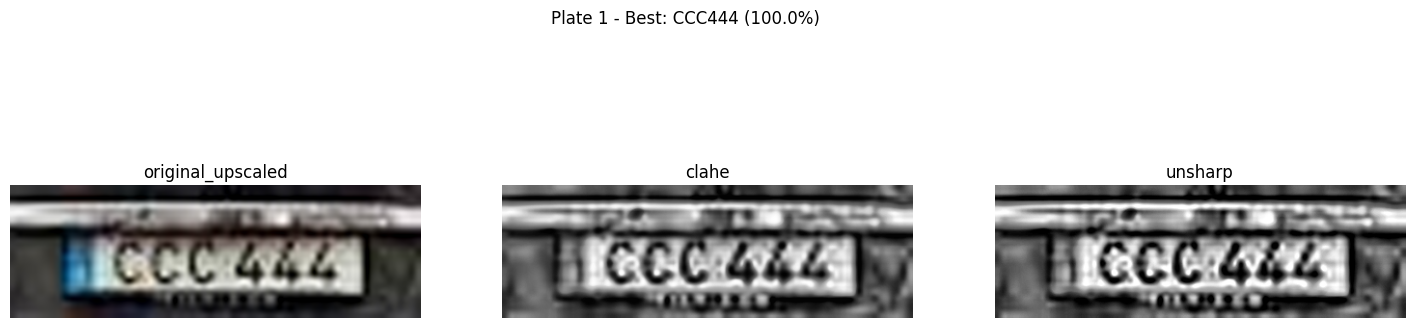

In [5]:
image_path = "/content/images (1).jpg"
image = cv2.imread(image_path)

if image is None:
    raise Exception("Image not found!")

results = model.predict(
    source=image,
    conf=0.25,
    imgsz=1280,
    verbose=False
)

result = results[0]

print("Number of detected plates:", len(result.boxes))

for i, box in enumerate(result.boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate = add_padding(
        image,
        x1, y1, x2, y2,
        pad_ratio=0.15
    )

    if plate.size == 0:
        continue

    plate = deskew_plate(plate)
    variants = preprocess_variants(plate)

    text, conf, variant_name, all_results = best_ocr_result(
        variants,
        ocr
    )

    print(f"\n==== Plate {i+1} ====")

    print("Results from all variants:")

    for name, t, c in all_results:
        print(f"  {name}: '{t}' ({c:.2%})")

    print(
        f"\n>>> Best Result: {text} | "
        f"Confidence: {conf:.2%} | "
        f"Variant: {variant_name}"
    )

    # Display results
    fig, axes = plt.subplots(
        1,
        len(variants),
        figsize=(18, 5)
    )

    for ax, (name, img) in zip(axes, variants.items()):
        ax.imshow(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )
        ax.set_title(name)
        ax.axis("off")

    plt.suptitle(
        f"Plate {i+1} - Best: {text} ({conf:.1%})"
    )

    plt.show()

Number of detected plates: 1

==== Plate 1 ====
Results from all variants:
  original_upscaled: 'M EV332E' (99.53%)
  clahe: 'M EV332E' (98.64%)
  unsharp: 'M EV332E' (98.46%)

>>> Best Result: M EV332E | Confidence: 99.53% | Variant: original_upscaled


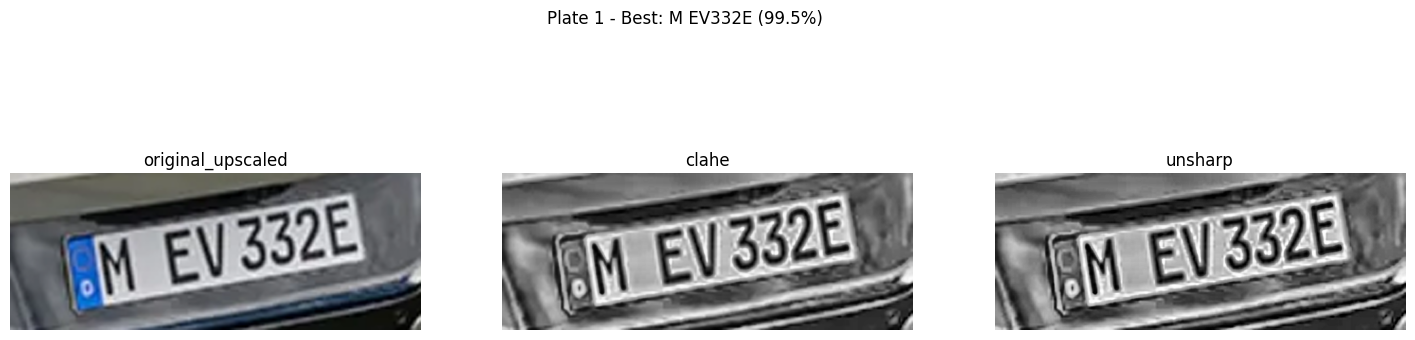

In [6]:
image_path = "/content/CR-Cars-InlineHero-2027-BMW-X5-r-driving-coast-7-26.webp"
image = cv2.imread(image_path)

if image is None:
    raise Exception("Image not found!")

results = model.predict(
    source=image,
    conf=0.25,
    imgsz=1280,
    verbose=False
)

result = results[0]

print("Number of detected plates:", len(result.boxes))

for i, box in enumerate(result.boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate = add_padding(
        image,
        x1, y1, x2, y2,
        pad_ratio=0.15
    )

    if plate.size == 0:
        continue

    plate = deskew_plate(plate)
    variants = preprocess_variants(plate)

    text, conf, variant_name, all_results = best_ocr_result(
        variants,
        ocr
    )

    print(f"\n==== Plate {i+1} ====")

    print("Results from all variants:")

    for name, t, c in all_results:
        print(f"  {name}: '{t}' ({c:.2%})")

    print(
        f"\n>>> Best Result: {text} | "
        f"Confidence: {conf:.2%} | "
        f"Variant: {variant_name}"
    )

    # Display results
    fig, axes = plt.subplots(
        1,
        len(variants),
        figsize=(18, 5)
    )

    for ax, (name, img) in zip(axes, variants.items()):
        ax.imshow(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )
        ax.set_title(name)
        ax.axis("off")

    plt.suptitle(
        f"Plate {i+1} - Best: {text} ({conf:.1%})"
    )

    plt.show()

In [4]:
import cv2
import numpy as np
from collections import defaultdict, Counter

video_path = "/content/2103099-uhd_3840_2160_30fps.mp4"
output_path = "/content/license_plate_video_result.mp4"

MAX_FRAMES = 500

OCR_EVERY_N_FRAMES = 10

YOLO_CONF = 0.25

YOLO_IMGSZ = 1280

MAX_MISSED_FRAMES = 30

def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_w = max(0, x2 - x1)
    intersection_h = max(0, y2 - y1)

    intersection = intersection_w * intersection_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union


def clean_ocr_text(text):

    if text is None:
        return ""

    text = str(text).strip()
    text = text.replace(" ", "")
    text = text.replace("\n", "")
    text = text.replace("-", "")
    text = text.replace("_", "")
    text = text.upper()

    return text


def get_best_track_text(track):

    history = track["ocr_history"]

    if not history:
        return "", 0.0

    valid_results = [
        item for item in history
        if item["text"]
    ]

    if not valid_results:
        return "", 0.0


    text_counter = Counter(
        item["text"]
        for item in valid_results
    )

    most_common_text, count = text_counter.most_common(1)[0]


    matching_scores = [
        item["conf"]
        for item in valid_results
        if item["text"] == most_common_text
    ]

    avg_conf = (
        sum(matching_scores) / len(matching_scores)
        if matching_scores
        else 0.0
    )

    return most_common_text, avg_conf


cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise Exception("مش قادر أفتح الفيديو!")

fps = cap.get(cv2.CAP_PROP_FPS)

if fps <= 0:
    fps = 30

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Video size:", width, "x", height)
print("Total frames in video:", total_frames)
print("Frames to process:", min(MAX_FRAMES, total_frames))


fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

if not out.isOpened():
    raise Exception("مش قادر أعمل output video!")


tracks = {}

next_track_id = 0


frame_number = 0

while frame_number < MAX_FRAMES:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1


    results = model.predict(
        source=frame,
        conf=YOLO_CONF,
        imgsz=YOLO_IMGSZ,
        verbose=False
    )

    result = results[0]

    detections = []

    for box in result.boxes:

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].cpu().numpy()
        )

        confidence = float(
            box.conf[0].cpu().numpy()
        )

        detections.append(
            {
                "box": (x1, y1, x2, y2),
                "conf": confidence
            }
        )



    matched_track_ids = set()

    current_track_ids = []


    for detection in detections:

        current_box = detection["box"]

        best_track_id = None
        best_iou = 0.0



        for track_id, track in tracks.items():

            if track_id in matched_track_ids:
                continue

            previous_box = track["box"]

            iou = calculate_iou(
                current_box,
                previous_box
            )

            if iou > best_iou:

                best_iou = iou
                best_track_id = track_id



        if best_track_id is not None and best_iou >= 0.30:

            track_id = best_track_id

            tracks[track_id]["box"] = current_box
            tracks[track_id]["last_seen"] = frame_number

            matched_track_ids.add(track_id)


        else:

            track_id = next_track_id

            next_track_id += 1

            tracks[track_id] = {

                "box": current_box,

                "last_seen": frame_number,

                "ocr_history": []

            }

            matched_track_ids.add(track_id)


        current_track_ids.append(track_id)



        x1, y1, x2, y2 = current_box

        plate = add_padding(
            frame,
            x1,
            y1,
            x2,
            y2,
            pad_ratio=0.15
        )


        if plate.size == 0:
            continue



        if frame_number % OCR_EVERY_N_FRAMES == 0:

            try:

                plate_for_ocr = deskew_plate(
                    plate
                )

                variants = preprocess_variants(
                    plate_for_ocr
                )

                text, conf, variant_name, all_results = best_ocr_result(
                    variants,
                    ocr
                )

                text = clean_ocr_text(text)



                if text:

                    tracks[track_id]["ocr_history"].append(
                        {
                            "text": text,
                            "conf": conf,
                            "frame": frame_number
                        }
                    )


                    if len(
                        tracks[track_id]["ocr_history"]
                    ) > 10:

                        tracks[track_id]["ocr_history"] = \
                            tracks[track_id]["ocr_history"][-10:]


                    print(
                        f"Frame {frame_number} | "
                        f"Track {track_id} | "
                        f"OCR: {text} | "
                        f"Confidence: {conf:.2%}"
                    )

            except Exception as e:

                print(
                    f"OCR Error - Frame {frame_number} "
                    f"Track {track_id}: {e}"
                )



        best_text, best_conf = get_best_track_text(
            tracks[track_id]
        )



        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )



        cv2.putText(
            frame,
            f"ID: {track_id}",
            (x1, max(y1 - 35, 25)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 0),
            2
        )



        if best_text:

            label = (
                f"{best_text} "
                f"({best_conf:.0%})"
            )

            text_size = cv2.getTextSize(
                label,
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                2
            )[0]

            label_y = max(
                y1 - 5,
                text_size[1] + 5
            )

            cv2.rectangle(
                frame,
                (
                    x1,
                    label_y - text_size[1] - 8
                ),
                (
                    x1 + text_size[0] + 8,
                    label_y + 5
                ),
                (0, 0, 0),
                -1
            )

            cv2.putText(
                frame,
                label,
                (x1 + 4, label_y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )



    tracks_to_delete = []

    for track_id, track in tracks.items():

        if (
            frame_number - track["last_seen"]
            > MAX_MISSED_FRAMES
        ):

            tracks_to_delete.append(
                track_id
            )


    for track_id in tracks_to_delete:

        del tracks[track_id]



    progress_text = (
        f"Frame {frame_number}/{min(MAX_FRAMES, total_frames)}"
    )

    cv2.putText(
        frame,
        progress_text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )



    out.write(frame)


    if frame_number % 25 == 0:

        print(
            f"Processed: "
            f"{frame_number}/"
            f"{min(MAX_FRAMES, total_frames)}"
        )




cap.release()
out.release()


print("Output:")
print(output_path)

FPS: 30.0
Video size: 3840 x 2160
Total frames in video: 1800
Frames to process: 500
Frame 10 | Track 0 | OCR: VSUMW51 | Confidence: 96.45%
Frame 10 | Track 3 | OCR: GXISOGJ | Confidence: 87.35%
Frame 10 | Track 1 | OCR: NA13NRU | Confidence: 94.06%
Frame 20 | Track 0 | OCR: MWSIVSU | Confidence: 90.96%
Frame 20 | Track 6 | OCR: NA13NRU | Confidence: 97.13%
Frame 20 | Track 3 | OCR: GX150GJ | Confidence: 95.66%
Frame 20 | Track 2 | OCR: 1 | Confidence: 49.96%
Processed: 25/500
Frame 30 | Track 0 | OCR: MW51VSU | Confidence: 92.17%
Frame 30 | Track 6 | OCR: NA13NRU | Confidence: 99.80%
Frame 30 | Track 3 | OCR: GX150GJ | Confidence: 96.28%
Frame 40 | Track 0 | OCR: WWSIVSU | Confidence: 80.51%
Frame 40 | Track 3 | OCR: GX15OGJ | Confidence: 95.80%
Frame 40 | Track 8 | OCR: 1 | Confidence: 45.45%
Frame 50 | Track 0 | OCR: MW51VSU | Confidence: 93.79%
Frame 50 | Track 3 | OCR: GX15OGJ | Confidence: 95.56%
Frame 50 | Track 7 | OCR: APOS | Confidence: 92.97%
Frame 50 | Track 8 | OCR: 40 | C